# Student Wellbeing Statistical Analysis & Probability



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Day16_Student_Wellbeing_Survey.csv")

print("Shape:", df.shape)
df.head()

Shape: (600, 20)


,Student_ID,Age,Faculty,Year_of_Study,City,Accommodation,Scholarship,Part_Time_Job,Internet_Quality,Preferred_Study_Space,Weekly_Study_Hours,Average_Sleep_Hours,Daily_Screen_Time_Hours,Exercise_Days_Per_Week,Commute_Time_Minutes,Stress_Score,Academic_Readiness_Score,Overall_Satisfaction,Monthly_Discretionary_Spending,Social_Activity_Hours_Per_Week
0,STU0001,21,Data Science,3,Bengaluru,Hostel,No,Yes,Good,Café,15.2,5.7,3.2,3,11.8,5.4,63.1,3.2,5131.0,7.8
1,STU0002,21,Data Science,4,Pune,Hostel,Yes,No,Poor,Library,17.6,7.7,3.5,4,20.3,2.1,74.2,3.8,3508.0,9.2
2,STU0003,22,Life Sciences,2,Chandigarh,Home,Yes,No,Poor,Home,18.9,6.4,2.8,1,15.0,5.2,77.3,4.0,4584.0,7.7
3,STU0004,18,Business,4,Bengaluru,Hostel,Yes,Yes,Average,Café,19.5,6.7,3.0,5,12.1,4.7,67.0,4.0,5456.0,5.3
4,STU0005,20,Business,3,Jammu,Shared Apartment,Yes,No,Good,Home,18.4,7.3,3.0,1,30.2,5.4,65.6,3.2,11732.0,15.9


In [2]:
df.info()
print("\nMissing values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Student_ID                      600 non-null    object 
 1   Age                             600 non-null    int64  
 2   Faculty                         600 non-null    object 
 3   Year_of_Study                   600 non-null    int64  
 4   City                            600 non-null    object 
 5   Accommodation                   600 non-null    object 
 6   Scholarship                     600 non-null    object 
 7   Part_Time_Job                   600 non-null    object 
 8   Internet_Quality                600 non-null    object 
 9   Preferred_Study_Space           600 non-null    object 
 10  Weekly_Study_Hours              600 non-null    float64
 11  Average_Sleep_Hours             600 non-null    float64
 12  Daily_Screen_Time_Hours         600 

## Descriptive Statistics



In [3]:
stats_vars = [
    "Weekly_Study_Hours",
    "Average_Sleep_Hours",
    "Daily_Screen_Time_Hours",
    "Stress_Score",
    "Academic_Readiness_Score"
]

summary = []
for col in stats_vars:
    s = df[col].dropna()
    summary.append({
        "Variable": col,
        "Mean": s.mean(),
        "Median": s.median(),
        "Mode": ", ".join(map(str, s.mode().tolist())),
        "Range": s.max() - s.min(),
        "Variance": s.var(),
        "Std_Dev": s.std(),
        "Q1": s.quantile(0.25),
        "Q3": s.quantile(0.75),
        "IQR": s.quantile(0.75) - s.quantile(0.25)
    })

stats_table = pd.DataFrame(summary)
stats_table.round(2)

,Variable,Mean,Median,Mode,Range,Variance,Std_Dev,Q1,Q3,IQR
0,Weekly_Study_Hours,15.69,15.40,"13.1, 14.6, 15.3, 17.1",30.0,19.22,4.38,13.00,18.42,5.42
1,Average_Sleep_Hours,7.00,7.00,7.0,5.0,0.70,0.84,6.48,7.60,1.12
2,Daily_Screen_Time_Hours,4.50,4.20,3.5,11.2,3.47,1.86,3.20,5.40,2.20
3,Stress_Score,4.46,4.50,"4.7, 4.9",8.4,2.78,1.67,3.30,5.70,2.40
4,Academic_Readiness_Score,71.77,71.65,"71.1, 71.4, 78.0",56.1,93.98,9.69,65.20,78.03,12.83


### Variability

Looking at standard deviation and variance, **Academic_Readiness_Score has the greatest variability among the variables when measured by variance (93.98)**. This is also the variable with the largest standard deviation in its own units (9.69), although the variables are on different scales.

## Outlier Detection Using IQR

Formula:

**IQR = Q3 - Q1**

**Lower limit = Q1 - 1.5 × IQR**

**Upper limit = Q3 + 1.5 × IQR**

Values outside these limits are treated as potential outliers.

In [4]:
outlier_vars = [
    "Weekly_Study_Hours",
    "Daily_Screen_Time_Hours",
    "Commute_Time_Minutes",
    "Monthly_Discretionary_Spending"
]

outlier_summary = []

for col in outlier_vars:
    s = df[col].dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = s[(s < lower) | (s > upper)]

    outlier_summary.append({
        "Variable": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Limit": lower,
        "Upper Limit": upper,
        "Outlier Count": len(outliers)
    })

outlier_table = pd.DataFrame(outlier_summary)
outlier_table.round(2)

,Variable,Q1,Q3,IQR,Lower Limit,Upper Limit,Outlier Count
0,Weekly_Study_Hours,13.00,18.42,5.42,4.86,26.56,8
1,Daily_Screen_Time_Hours,3.20,5.40,2.20,-0.10,8.70,18
2,Commute_Time_Minutes,13.38,31.52,18.15,-13.85,58.75,4
3,Monthly_Discretionary_Spending,4113.00,7808.50,3695.50,-1430.25,13351.75,20


### Example: Weekly Study Hours Before and After Removing Outliers

In [5]:
col = "Weekly_Study_Hours"
s = df[col].dropna()

q1 = s.quantile(0.25)
q3 = s.quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

s_no_outliers = s[(s >= lower) & (s <= upper)]

comparison = pd.DataFrame({
    "Measure": ["Mean", "Median"],
    "Before Removing Outliers": [s.mean(), s.median()],
    "After Removing Outliers": [s_no_outliers.mean(), s_no_outliers.median()]
})

comparison.round(2)

,Measure,Before Removing Outliers,After Removing Outliers
0,Mean,15.69,15.60
1,Median,15.40,15.35


The mean changes slightly after removing the detected outliers, while the median changes very little. This is expected because the median is less affected by extreme values than the mean.

## Probability Analysis

Events:

- **A:** Part_Time_Job = Yes
- **B:** Stress_Score ≥ 7
- **C:** Scholarship = Yes
- **D:** Exercise_Days_Per_Week ≥ 3

For an event E:

**P(E) = Number of favorable outcomes / Total number of students**

In [6]:
A = df["Part_Time_Job"].eq("Yes")
B = df["Stress_Score"].ge(7)
C = df["Scholarship"].eq("Yes")
D = df["Exercise_Days_Per_Week"].ge(3)

n = len(df)

probabilities = {
    "P(A)": A.mean(),
    "P(B)": B.mean(),
    "P(C)": C.mean(),
    "P(D)": D.mean(),
    "P(A or B)": (A | B).mean(),
    "P(A and B)": (A & B).mean(),
    "P(A|B)": (A & B).sum() / B.sum(),
    "P(B|A)": (A & B).sum() / A.sum()
}

pd.Series(probabilities).round(4)

,0
P(A),0.2533
P(B),0.0750
P(C),0.3067
P(D),0.5933
P(A or B),0.2767
P(A and B),0.0517
P(A|B),0.6889
P(B|A),0.2039


### Mutually Exclusive Events

Year 1 and Year 4 cannot happen for the same student at the same time. Therefore, **Year_of_Study = 1 and Year_of_Study = 4 are mutually exclusive events**.

Their intersection is empty, so:

**P(Year 1 and Year 4) = 0**

## Are A and B Independent?

Two events are independent if:

**P(A and B) = P(A) × P(B)**

In [7]:
p_a = A.mean()
p_b = B.mean()
p_ab = (A & B).mean()
independent_product = p_a * p_b

print("P(A and B) =", round(p_ab, 4))
print("P(A) × P(B) =", round(independent_product, 4))

if np.isclose(p_ab, independent_product):
    print("A and B appear independent.")
else:
    print("A and B do not appear independent.")

P(A and B) = 0.0517
P(A) × P(B) = 0.019
A and B do not appear independent.


Here, **P(A and B) = 0.0517**, while **P(A) × P(B) = 0.0190**. Since the two values are clearly different, A and B do **not** appear independent in this dataset. This suggests that having a part-time job and having a high stress score are related in this sample.

## Bayes' Theorem

Bayes' theorem:

**P(A|B) = [P(B|A) × P(A)] / [P(B|A) × P(A) + P(B|not A) × P(not A)]**

In [8]:
p_a = A.mean()
p_not_a = (~A).mean()
p_b_given_a = (A & B).sum() / A.sum()
p_b_given_not_a = ((~A) & B).sum() / (~A).sum()

p_a_given_b_bayes = (
    p_b_given_a * p_a
) / (
    p_b_given_a * p_a + p_b_given_not_a * p_not_a
)

p_a_given_b_direct = (A & B).sum() / B.sum()

print("P(B|A) =", round(p_b_given_a, 4))
print("P(B|not A) =", round(p_b_given_not_a, 4))
print("P(A) =", round(p_a, 4))
print("P(A|B) using Bayes =", round(p_a_given_b_bayes, 4))
print("P(A|B) directly =", round(p_a_given_b_direct, 4))

P(B|A) = 0.2039
P(B|not A) = 0.0312
P(A) = 0.2533
P(A|B) using Bayes = 0.6889
P(A|B) directly = 0.6889


The Bayes result and the direct conditional probability result are both **0.6889**, so the calculation is verified.

## Academic Readiness Score and Normal Distribution

For a value x, the Z-score is:

**Z = (x - mean) / standard deviation**

A positive Z-score means the value is above the mean, while a negative Z-score means it is below the mean.

In [9]:
scores = df["Academic_Readiness_Score"].dropna()
mean_score = scores.mean()
std_score = scores.std()

max_idx = scores.idxmax()
min_idx = scores.idxmin()

max_score = scores.loc[max_idx]
min_score = scores.loc[min_idx]

z_max = (max_score - mean_score) / std_score
z_min = (min_score - mean_score) / std_score

print("Mean:", round(mean_score, 2))
print("Standard deviation:", round(std_score, 2))
print("\nHighest score:", max_score, "| Student:", df.loc[max_idx, "Student_ID"])
print("Z-score:", round(z_max, 2))
print("\nLowest score:", min_score, "| Student:", df.loc[min_idx, "Student_ID"])
print("Z-score:", round(z_min, 2))

Mean: 71.77
Standard deviation: 9.69

Highest score: 98.0 | Student: STU0131
Z-score: 2.71

Lowest score: 41.9 | Student: STU0543
Z-score: -3.08


### Z-score Interpretation

- The highest Academic Readiness Score is **98.0**, with a Z-score of about **+2.71**. This student is around 2.7 standard deviations above the mean, so the score is unusually high.
- The lowest score is **41.9**, with a Z-score of about **-3.08**. This student is just over 3 standard deviations below the mean, so the score is unusually low.

### 68-95-99.7 Empirical Rule

If the data follows an approximately normal distribution:

- Within **1 standard deviation** → about **68%** of students
- Within **2 standard deviations** → about **95%** of students
- Within **3 standard deviations** → about **99.7%** of students

These are expected percentages from the empirical rule, not exact percentages calculated from this sample.

## A Few Visual Checks

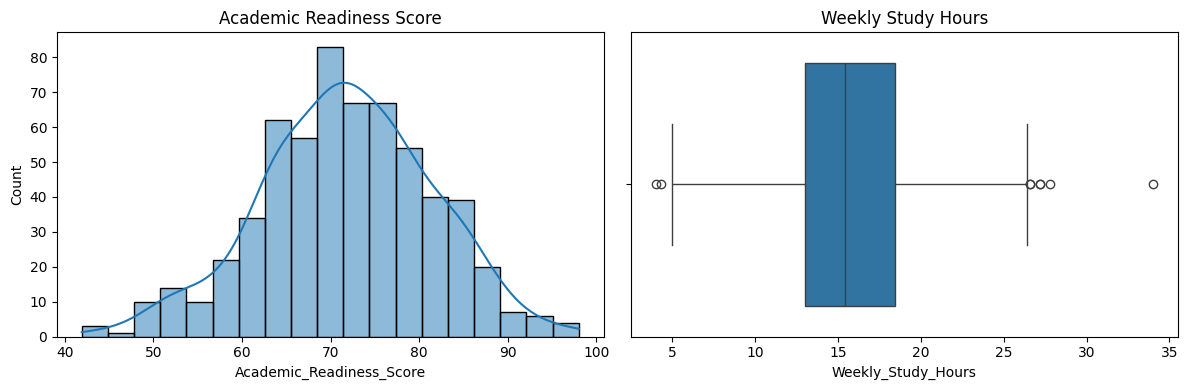

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["Academic_Readiness_Score"], kde=True, ax=axes[0])
axes[0].set_title("Academic Readiness Score")

sns.boxplot(x=df["Weekly_Study_Hours"], ax=axes[1])
axes[1].set_title("Weekly Study Hours")

plt.tight_layout()
plt.show()

## Five Statistical Observations

1. **Academic readiness has the greatest overall variability** among the main numerical variables when comparing variance.
2. **Weekly study hours have a relatively small number of IQR outliers**, mainly at unusually low or high study-hour values.
3. **Around 59% of students exercise at least 3 days per week**, which is more common than having a part-time job.
4. **High stress (score ≥ 7) is less common in the sample, but it is much more frequent among students with part-time jobs**, suggesting a relationship between the two events.
5. **The extreme Academic Readiness scores are quite far from the mean**: the highest is about 2.7 standard deviations above it and the lowest is just over 3 standard deviations below it.

## Conclusion

This analysis shows how descriptive statistics, outlier detection, probability, conditional probability, Bayes' theorem, and Z-scores can be used together to understand student wellbeing data. The probability results especially show that part-time work and high stress are not behaving like independent events in this sample, while the Academic Readiness scores also give a useful view of how far individual students are from the average.